<a href="https://colab.research.google.com/github/Anggasaputraramadhan/Pembelajaran-Mesin/blob/main/Kuis1_PembelajaranMesin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# This is formatted as code
```

# 📊 Kuis 1 Machine Learning - EDA & Preprocessing
Soal kuis berbasis dataset TI-3B. Buat dataset TI-3B dengan fitur sebagai berikut: nama lengkap, jenis kelamin, kota asal, tinggi badan(cm), asal kelas, target IP semester 5, warna kesukaan, hobi, film favorit, warna favorit, genre musik, idola, kota favorit, makanan favorit, minuman favorit, negara yang ingin dikunjungi.
Silakan kerjakan langsung di Colab dengan mengisi kode dan jawabanmu.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from google.colab import drive

drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Pembelajaran Mesin/Dataset TI-3B.xlsx"

if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"Dataset tidak ditemukan di:\n{file_path}"
    )

df = pd.read_excel(file_path, sheet_name="Sheet1")

print(f"Dataset berhasil dimuat!")
print(f"Jumlah baris : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset berhasil dimuat!
Jumlah baris : 25
Jumlah kolom : 16


,no,nama lengkap,jenis kelamin,kota asal,tinggi badan (cm),asal kelas,target IP smt 5,warna kesukaan,hobi,film fav,genre musik,idola,kota fav,makanan fav,minuman fav,negara yang ingin dikunjungi
0,1,Alfreda Dhaifullah Mahezwara,L,Malang,172,2C,4,Red Marron,Main ML,The Shadow Edge,Britpop,Jackable,"malang,batu",Nasi Goreng,Es Teler,China
1,2,Angga Saputra Ramadhan,L,Probolinggo,163,2B,4,Putih,Sepak Bola,Semua,Electropop,Neymar Jr,Malang,Ayam Geprek,Capuccino,Thailand
2,3,Ardhan Dikri Achmad Fahrudin,L,Malang,172,2H,4,Biru,Basket,Toy Story,Pop,Messi,Labuan Bajo,Tahu Telor,Hot V60,Swiss
3,4,Arjuna Carly Dhymas Mahendra,L,Sidoarjo,165,2B,4,Biru,Basket,Seven,Rock,Ronaldo,Bandung,Sate Ayam,Air Mineral,Swiss
4,5,Arya Ramadhan,L,Malang,175,2G,4,Ungu,Berenang,Lucifer (2016-2021)`,Pop,Diana Rider,Malang,Oyi Buttermilk,KAPITEN,UK


In [6]:
NAMA_KAMU = "Angga Saputra Ramadhan"
KOTA_ASAL_KAMU = "Probolinggo"
TINGGI_KAMU = 163.0
IPS_TARGET_KAMU = 4
WARNA_KAMU = "Putih"
MAKANAN_KAMU = "Ayam Geprek"
MINUMAN_KAMU = "Cappucino"
KELAS_KAMU = "3B"

print("Data diri siap digunakan.")


Data diri siap digunakan.


## Soal 1
Hitung rata-rata tinggi badan mahasiswa **yang asal kotanya sama dengan kamu**.

- Bersihkan data asal kota dulu, jika ada data yang berisi "kota madiun", "kabupaten malang" bersihkan hingga hanya menjadi "madiun" dan "malang"
- Bandingkan tinggi badanmu dengan rata-rata kota asal.
- Apakah kamu lebih tinggi atau lebih rendah dari rata-rata tersebut?

In [7]:
def bersihkan_kota(x):
    s = str(x).strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"^(kota|kabupaten)\s+", "", s)
    return s

df["kota_bersih"] = df["kota asal"].apply(bersihkan_kota)
df["tinggi_num"] = pd.to_numeric(df["tinggi badan (cm)"], errors="coerce")

kota_user = bersihkan_kota(KOTA_ASAL_KAMU)
data_kota = df[df["kota_bersih"] == kota_user].copy()
rata_tinggi_kota = data_kota["tinggi_num"].mean()

print("Data mahasiswa dengan kota asal sama:")
display(data_kota[["nama lengkap", "kota asal", "tinggi_num"]])
print(f"Rata-rata tinggi badan asal {KOTA_ASAL_KAMU}: {rata_tinggi_kota:.2f} cm")
print(f"Tinggi badan kamu: {TINGGI_KAMU:.2f} cm")


Data mahasiswa dengan kota asal sama:


,nama lengkap,kota asal,tinggi_num
1,Angga Saputra Ramadhan,Probolinggo,163


Rata-rata tinggi badan asal Probolinggo: 163.00 cm
Tinggi badan kamu: 163.00 cm


In [8]:
if TINGGI_KAMU > rata_tinggi_kota:
    kesimpulan_1 = "Tinggi badan kamu lebih tinggi daripada rata-rata kota asal."
elif TINGGI_KAMU < rata_tinggi_kota:
    kesimpulan_1 = "Tinggi badan kamu lebih rendah daripada rata-rata kota asal."
else:
    kesimpulan_1 = "Tinggi badan kamu sama dengan rata-rata kota asal."
print(kesimpulan_1)

Tinggi badan kamu sama dengan rata-rata kota asal.


## Soal 2
Kolom **Target IP semester 5 ini** memiliki variasi format (angka, teks, koma/titik).

- Bersihkan kolom menjadi numerik.
- Lakukan normalisasi Min-Max.
- Berapa nilai normalisasi IPS target kamu sendiri?

In [9]:
def bersihkan_ips(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(",", ".")
    match = re.search(r"\d+(?:\.\d+)?", s)
    return float(match.group()) if match else np.nan

df["ips_numerik"] = df["target IP smt 5"].apply(bersihkan_ips)

scaler = MinMaxScaler()
df["ips_normalisasi"] = scaler.fit_transform(df[["ips_numerik"]])

display(df[["nama lengkap", "target IP smt 5", "ips_numerik", "ips_normalisasi"]].head(10))
nilai_ips_kamu = float(df.loc[df["nama lengkap"].eq(NAMA_KAMU), "ips_normalisasi"].iloc[0])
print(f"Nilai normalisasi IPS target kamu ({IPS_TARGET_KAMU}): {nilai_ips_kamu:.2f}")

print(f"Min IPS = {df['ips_numerik'].min():.2f}")
print(f"Max IPS = {df['ips_numerik'].max():.2f}")
if df["ips_numerik"].nunique() == 1:
    print("Semua nilai IPS pada dataset adalah 4, sehingga rentang (max-min) = 0.")
    print("Rumus Min-Max manual menjadi 0/0 (tidak terdefinisi). MinMaxScaler sklearn menangani kondisi ini dengan menghasilkan 0.00.")
print(f"Kesimpulan: nilai normalisasi IPS target kamu = {nilai_ips_kamu:.2f}.")

,nama lengkap,target IP smt 5,ips_numerik,ips_normalisasi
0,Alfreda Dhaifullah Mahezwara,4,4.0,0.0
1,Angga Saputra Ramadhan,4,4.0,0.0
2,Ardhan Dikri Achmad Fahrudin,4,4.0,0.0
3,Arjuna Carly Dhymas Mahendra,4,4.0,0.0
4,Arya Ramadhan,4,4.0,0.0
5,Ayu Annisa Aryani Nagari,4,4.0,0.0
6,Bagus Wichaksono Amanulloh,4,4.0,0.0
7,Burhanuddin Ihsan,4,4.0,0.0
8,Daana Hafidhil Islam,4,4.0,0.0
9,Dewi Anggraini Meita Sari,4,4.0,0.0


Nilai normalisasi IPS target kamu (4): 0.00
Min IPS = 4.00
Max IPS = 4.00
Semua nilai IPS pada dataset adalah 4, sehingga rentang (max-min) = 0.
Rumus Min-Max manual menjadi 0/0 (tidak terdefinisi). MinMaxScaler sklearn menangani kondisi ini dengan menghasilkan 0.00.
Kesimpulan: nilai normalisasi IPS target kamu = 0.00.


## Soal 3
Lakukan **Label Encoding** pada kolom **Warna kesukaan**.

- Tampilkan hasil encoding warna kesukaanmu sendiri.
- Apakah warnamu termasuk kode terkecil, terbesar, atau di tengah?

In [10]:
df["warna_bersih"] = df["warna kesukaan"].astype(str).str.strip()
le = LabelEncoder()
df["warna_encoded"] = le.fit_transform(df["warna_bersih"])

mapping_warna = pd.DataFrame({"Warna": le.classes_, "Kode": range(len(le.classes_))})
display(mapping_warna)

kode_warna_kamu = int(le.transform([WARNA_KAMU])[0])
print(f"Warna kamu: {WARNA_KAMU}")
print(f"Kode Label Encoding warna kamu: {kode_warna_kamu}")

kode_min = int(df["warna_encoded"].min())
kode_max = int(df["warna_encoded"].max())
median_kode = df["warna_encoded"].median()
print(f"Kode terkecil: {kode_min}")
print(f"Kode terbesar: {kode_max}")
print(f"Median kode: {median_kode:.1f}")
if kode_warna_kamu == kode_min:
    posisi_warna = "terkecil"
elif kode_warna_kamu == kode_max:
    posisi_warna = "terbesar"
elif kode_warna_kamu == median_kode:
    posisi_warna = "tepat di tengah"
else:
    posisi_warna = "bukan terkecil/terbesar; berada di atas posisi tengah" if kode_warna_kamu > median_kode else "bukan terkecil/terbesar; berada di bawah posisi tengah"
print(f"Kesimpulan: kode warna {WARNA_KAMU} = {kode_warna_kamu}, {posisi_warna}.")

,Warna,Kode
0,Abu,0
1,Biru,1
2,Biru Tua,2
3,Hitam,3
4,Kuning,4
5,Maroon,5
6,Merah Muda,6
7,Pink,7
8,Putih,8
9,Red Marron,9


Warna kamu: Putih
Kode Label Encoding warna kamu: 8
Kode terkecil: 0
Kode terbesar: 13
Median kode: 4.0
Kesimpulan: kode warna Putih = 8, bukan terkecil/terbesar; berada di atas posisi tengah.


## Soal 4
Kelompokkan data berdasarkan **Jenis kelamin**.

- Hitung rata-rata tinggi badan tiap kelompok.
- Bandingkan tinggi badanmu dengan rata-rata kelompokmu.

In [11]:
rata_tinggi_gender = df.groupby("jenis kelamin")["tinggi_num"].mean().round(2)
display(rata_tinggi_gender.rename("rata-rata tinggi (cm)").to_frame())

gender_kamu = df.loc[df["nama lengkap"].eq(NAMA_KAMU), "jenis kelamin"].iloc[0]
rata_gender_kamu = float(rata_tinggi_gender.loc[gender_kamu])
print(f"Jenis kelamin kamu pada dataset: {gender_kamu}")
print(f"Rata-rata tinggi kelompok {gender_kamu}: {rata_gender_kamu:.2f} cm")
print(f"Tinggi kamu: {TINGGI_KAMU:.2f} cm")

if TINGGI_KAMU > rata_gender_kamu:
    print("Kesimpulan: tinggi badan kamu lebih tinggi daripada rata-rata kelompok jenis kelamin kamu.")
elif TINGGI_KAMU < rata_gender_kamu:
    print("Kesimpulan: tinggi badan kamu lebih rendah daripada rata-rata kelompok jenis kelamin kamu.")
else:
    print("Kesimpulan: tinggi badan kamu sama dengan rata-rata kelompok jenis kelamin kamu.")

,rata-rata tinggi (cm)
jenis kelamin,
L,171.89
P,157.86


Jenis kelamin kamu pada dataset: L
Rata-rata tinggi kelompok L: 171.89 cm
Tinggi kamu: 163.00 cm
Kesimpulan: tinggi badan kamu lebih rendah daripada rata-rata kelompok jenis kelamin kamu.


## Soal 5 (pilih 2 fitur dari fitur yang ada)
Selanjutnya buat bar chart distribusi (misal)**Makanan favorit dan minuman favorit**.

- Dari grafik tersebut, apakah makanan dan minuman favoritmu termasuk dominan atau minoritas?

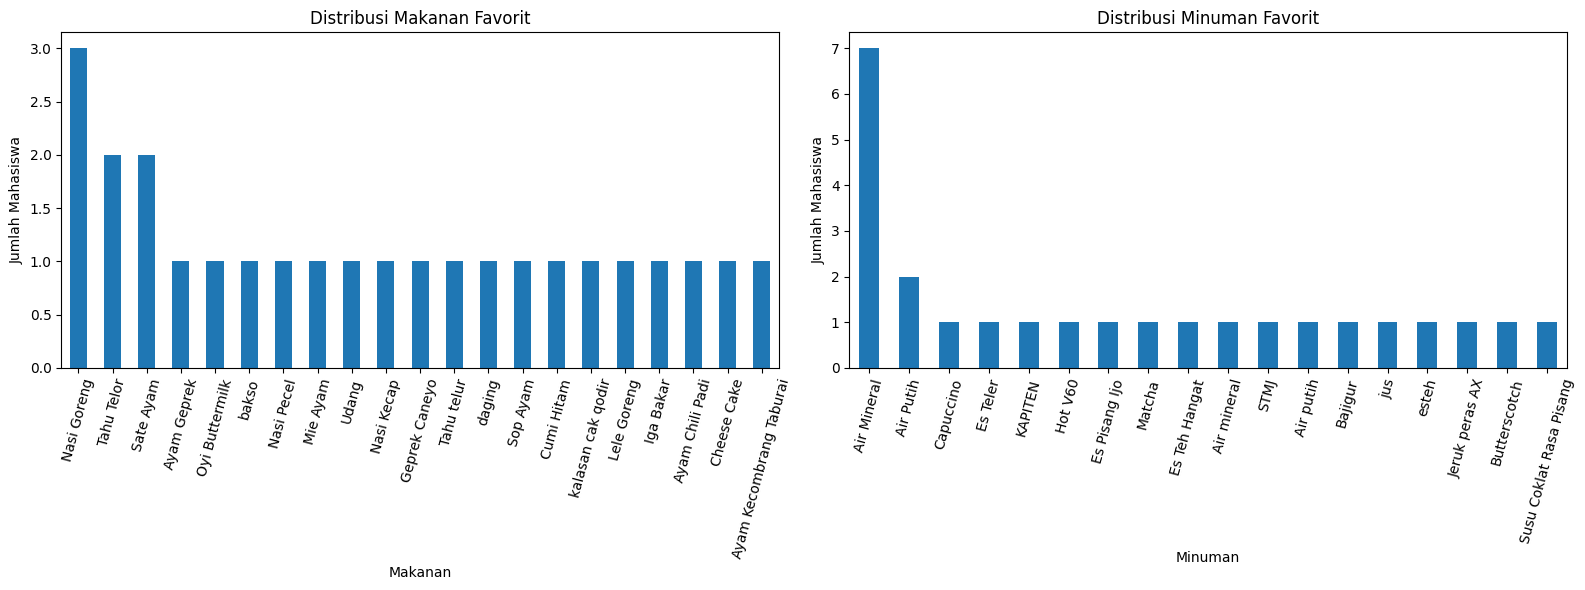

Ayam Geprek: 1 mahasiswa
Cappucino: 1 mahasiswa (dataset tertulis 'Capuccino')
Makanan paling banyak dipilih: Nasi Goreng (3 mahasiswa)
Minuman paling banyak dipilih: Air Mineral (7 mahasiswa)
Kesimpulan Soal 5:
- Ayam Geprek termasuk minoritas karena dipilih 1 mahasiswa, sedangkan pilihan terbanyak adalah Nasi Goreng (3).
- Cappucino termasuk minoritas karena dipilih 1 mahasiswa, sedangkan pilihan terbanyak adalah Air Mineral (7).


In [12]:
makanan_counts = df["makanan fav"].astype(str).str.strip().value_counts()
minuman_counts = df["minuman fav"].astype(str).str.strip().value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
makanan_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Distribusi Makanan Favorit")
axes[0].set_xlabel("Makanan")
axes[0].set_ylabel("Jumlah Mahasiswa")
axes[0].tick_params(axis="x", rotation=75)

minuman_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title("Distribusi Minuman Favorit")
axes[1].set_xlabel("Minuman")
axes[1].set_ylabel("Jumlah Mahasiswa")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

alias_minuman = {"cappucino": "capuccino"}
minuman_user_key = alias_minuman.get(MINUMAN_KAMU.strip().lower(), MINUMAN_KAMU.strip().lower())
minuman_counts_lower = minuman_counts.copy()
minuman_counts_lower.index = minuman_counts_lower.index.str.lower()

jumlah_makanan_kamu = int(makanan_counts.get(MAKANAN_KAMU, 0))
jumlah_minuman_kamu = int(minuman_counts_lower.get(minuman_user_key, 0))

print(f"{MAKANAN_KAMU}: {jumlah_makanan_kamu} mahasiswa")
print(f"{MINUMAN_KAMU}: {jumlah_minuman_kamu} mahasiswa (dataset tertulis 'Capuccino')")
print(f"Makanan paling banyak dipilih: {makanan_counts.idxmax()} ({makanan_counts.max()} mahasiswa)")
print(f"Minuman paling banyak dipilih: {minuman_counts.idxmax()} ({minuman_counts.max()} mahasiswa)")

print("Kesimpulan Soal 5:")
print(f"- {MAKANAN_KAMU} termasuk minoritas karena dipilih {jumlah_makanan_kamu} mahasiswa, sedangkan pilihan terbanyak adalah {makanan_counts.idxmax()} ({makanan_counts.max()}).")
print(f"- {MINUMAN_KAMU} termasuk minoritas karena dipilih {jumlah_minuman_kamu} mahasiswa, sedangkan pilihan terbanyak adalah {minuman_counts.idxmax()} ({minuman_counts.max()}).")

## Soal 6
Gunakan metode **IQR (Interquartile Range)** untuk mendeteksi outlier tinggi badan.

- Apakah tinggi badanmu termasuk outlier atau tidak?

In [13]:
Q1 = df["tinggi_num"].quantile(0.25)
Q3 = df["tinggi_num"].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier_mask = (df["tinggi_num"] < batas_bawah) | (df["tinggi_num"] > batas_atas)
outlier_data = df.loc[outlier_mask, ["nama lengkap", "tinggi_num"]]

print(f"Q1 = {Q1:.2f} cm")
print(f"Q3 = {Q3:.2f} cm")
print(f"IQR = {IQR:.2f} cm")
print(f"Batas bawah = {batas_bawah:.2f} cm")
print(f"Batas atas = {batas_atas:.2f} cm")
print("\nData outlier:")
display(outlier_data)

is_outlier_kamu = TINGGI_KAMU < batas_bawah or TINGGI_KAMU > batas_atas
if is_outlier_kamu:
    print(f"Tinggi kamu ({TINGGI_KAMU:.0f} cm) termasuk OUTLIER.")
else:
    print(f"Tinggi kamu ({TINGGI_KAMU:.0f} cm) TIDAK termasuk outlier.")
print(f"Karena {batas_bawah:.1f} <= {TINGGI_KAMU:.1f} <= {batas_atas:.1f}.")

Q1 = 160.00 cm
Q3 = 175.00 cm
IQR = 15.00 cm
Batas bawah = 137.50 cm
Batas atas = 197.50 cm

Data outlier:


,nama lengkap,tinggi_num


Tinggi kamu (163 cm) TIDAK termasuk outlier.
Karena 137.5 <= 163.0 <= 197.5.


## Soal 7
Bersihkan kolom **Asal kelas** (hapus spasi berlebih, seragamkan huruf kapitalisasi).

- Hitung jumlah mahasiswa per kelas.
- Apakah kamu termasuk di kelas dengan jumlah terbanyak, menengah, atau sedikit?

In [14]:
df["kelas_bersih"] = (
    df["asal kelas"].astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.upper()
)

jumlah_per_kelas = df["kelas_bersih"].value_counts().sort_index()
display(jumlah_per_kelas.rename("jumlah mahasiswa").to_frame())

jumlah_kelas_kamu = int(jumlah_per_kelas.get(KELAS_KAMU.strip().upper(), 0))
maks_kelas = int(jumlah_per_kelas.max())
min_kelas = int(jumlah_per_kelas.min())
kelas_terbanyak = jumlah_per_kelas[jumlah_per_kelas == maks_kelas].index.tolist()
kelas_tersedikit = jumlah_per_kelas[jumlah_per_kelas == min_kelas].index.tolist()

print(f"Kelas kamu (sesuai data diri yang diberikan): {KELAS_KAMU}")
print(f"Jumlah mahasiswa kelas {KELAS_KAMU}: {jumlah_kelas_kamu}")
print(f"Kelas dengan jumlah terbanyak: {kelas_terbanyak} ({maks_kelas} mahasiswa)")
print(f"Kelas dengan jumlah tersedikit: {kelas_tersedikit} ({min_kelas} mahasiswa)")

if jumlah_kelas_kamu == maks_kelas:
    posisi_kelas = "terbanyak"
elif jumlah_kelas_kamu == min_kelas:
    posisi_kelas = "sedikit"
else:
    posisi_kelas = "menengah"

print(f"Kesimpulan: berdasarkan KELAS_KAMU = '{KELAS_KAMU}', kelas kamu termasuk kategori {posisi_kelas}.")
print("\nCatatan penting:")
print("- Data diri yang diberikan menyebut kelas 3B.")
print("- Pada baris nama kamu di dataset, kolom 'asal kelas' tercatat 2B.")
print("- Kode mengikuti KELAS_KAMU = '3B' sesuai data diri yang diberikan, sehingga jumlah 3B dihitung dari dataset.")

,jumlah mahasiswa
kelas_bersih,
2A,4
2B,7
2C,6
2E,1
2F,2
2G,3
2H,2


Kelas kamu (sesuai data diri yang diberikan): 3B
Jumlah mahasiswa kelas 3B: 0
Kelas dengan jumlah terbanyak: ['2B'] (7 mahasiswa)
Kelas dengan jumlah tersedikit: ['2E'] (1 mahasiswa)
Kesimpulan: berdasarkan KELAS_KAMU = '3B', kelas kamu termasuk kategori menengah.

Catatan penting:
- Data diri yang diberikan menyebut kelas 3B.
- Pada baris nama kamu di dataset, kolom 'asal kelas' tercatat 2B.
- Kode mengikuti KELAS_KAMU = '3B' sesuai data diri yang diberikan, sehingga jumlah 3B dihitung dari dataset.


## Ringkasan Hasil Berdasarkan Dataset

- **Soal 1:** Probolinggo hanya memiliki 1 data mahasiswa, yaitu tinggi 163 cm, sehingga rata-ratanya **163 cm**. Tinggi kamu **sama dengan** rata-rata.
- **Soal 2:** Semua nilai `target IP smt 5` pada dataset adalah **4**, sehingga `MinMaxScaler` menghasilkan **0.00** untuk nilai kamu. Secara rumus manual, jika semua nilai sama maka pembagian `(x-min)/(max-min)` menjadi 0/0 dan tidak terdefinisi.
- **Soal 3:** Label Encoding `Putih` menghasilkan kode **8**. Kode ini bukan yang terkecil atau terbesar dan berada **di atas median kode**.
- **Soal 4:** Rata-rata tinggi kelompok L = **171.89 cm**, sedangkan tinggi kamu = **163 cm**, sehingga tinggi kamu **lebih rendah** dari rata-rata kelompok L.
- **Soal 5:** `Ayam Geprek` dipilih **1** mahasiswa dan `Capuccino` (ejaan pada dataset) dipilih **1** mahasiswa. Keduanya termasuk **minoritas**.
- **Soal 6:** Q1 = **160 cm**, Q3 = **175 cm**, IQR = **15 cm**, batas outlier = **137.5–197.5 cm**. Tinggi 163 cm **tidak termasuk outlier**.
- **Soal 7:** Dataset memiliki kelas 2A–2H (tanpa 2D): 2A=4, 2B=7, 2C=6, 2E=1, 2F=2, 2G=3, 2H=2. Karena data diri yang diberikan adalah **3B**, jumlah 3B pada dataset adalah **0** sehingga masuk kategori **sedikit**. **Catatan:** baris nama kamu pada dataset justru tercatat di kelas **2B**, sehingga ada ketidaksesuaian antara data diri yang diberikan dan dataset.
